# Train TabR silang phase

- model `before`: train/val dari `before`, external dari `after`
- model `after`: train/val dari `after`, external dari `before`
- split train/val mengikuti pola v9/v8: event-based, bukan subject-held-out


In [1]:
import os
import re
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'preprocess-anxiety':
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Project root: {ROOT}')


Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [2]:
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from joblib import dump
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

from core.data_module import TabRDataModule
from core.TabR import LitTabR


In [3]:
FEATURES_PATH = ROOT / 'output/apex/features/poc_abs_flatten_ordered.xlsx'
TRAIN_ROOT = ROOT / 'output/apex/train'
N_EXTERNAL_PER_LABEL = 20
BATCH_SIZE = 128
MAX_EPOCHS = 50
RANDOM_SEED = 42
THRESHOLD = 0.5
LR = 3e-4
FREEZE_CONTEXT_EPOCH = MAX_EPOCHS // 4
M_NEIGHBORS = 8
EARLY_STOPPING_PATIENCE = 6
PHASES = ['before', 'after']
PHASE_SWAP = {'before': 'after', 'after': 'before'}

TRAIN_ROOT.mkdir(parents=True, exist_ok=True)
print(FEATURES_PATH)
print(TRAIN_ROOT)
print({'lr': LR, 'freeze_context_epoch': FREEZE_CONTEXT_EPOCH, 'm': M_NEIGHBORS, 'patience': EARLY_STOPPING_PATIENCE})


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/features/poc_abs_flatten_ordered.xlsx
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train
{'lr': 0.0003, 'freeze_context_epoch': 12, 'm': 8, 'patience': 6}


In [4]:
def get_next_train_dir(train_root: Path) -> Path:
    existing = []
    for path in train_root.iterdir():
        if path.is_dir() and re.fullmatch(r't\d+', path.name):
            existing.append(int(path.name[1:]))
    next_idx = max(existing, default=0) + 1
    out_dir = train_root / f't{next_idx}'
    out_dir.mkdir(parents=True, exist_ok=False)
    return out_dir


def plot_lightning_metrics(metrics_csv):
    df = pd.read_csv(metrics_csv)
    if 'epoch' not in df.columns:
        raise ValueError('Kolom epoch tidak ada')
    df_epoch = df.sort_values('step').groupby('epoch', as_index=False).last()

    plt.figure()
    if 'train_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_loss'], label='Train Loss')
    if 'val_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    if 'train_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_acc'], label='Train Accuracy')
    if 'val_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_acc'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


def visualize_results(model_dir):
    model_dir = str(model_dir).rstrip('/')
    for name, path in {
        'Internal': os.path.join(model_dir, 'cm_internal.png'),
        'External': os.path.join(model_dir, 'cm_external.png'),
    }.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue
        img = mpimg.imread(path)
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(name)
        plt.show()

    for name, path in {
        'Internal': os.path.join(model_dir, 'report_internal.csv'),
        'External': os.path.join(model_dir, 'report_external.csv'),
    }.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue
        print(f'\n=== {name.upper()} CLASSIFICATION REPORT ===')
        print(pd.read_csv(path, index_col=0))


def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            prob = torch.softmax(logits, dim=1)[:, 1]
            preds = (prob > threshold).long()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, average=None)
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'support': sup,
        'cm': confusion_matrix(y_true, y_pred),
        'report': classification_report(y_true, y_pred, output_dict=True),
    }


def save_confusion_matrix(cm, labels, out_path, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def balance_context_by_label(X, y, max_per_class=None):
    idx0 = (y == 0).nonzero(as_tuple=True)[0]
    idx1 = (y == 1).nonzero(as_tuple=True)[0]
    n = min(len(idx0), len(idx1))
    if max_per_class is not None:
        n = min(n, max_per_class)
    idx0 = idx0[torch.randperm(len(idx0))[:n]]
    idx1 = idx1[torch.randperm(len(idx1))[:n]]
    idx = torch.cat([idx0, idx1])
    idx = idx[torch.randperm(len(idx))]
    return X[idx], y[idx]


def balanced_external_events(event_table: pd.DataFrame, n_per_label: int, seed: int = 42) -> set[str]:
    rng = random.Random(seed)
    selected_ids = []
    for label_name in ['anxiety_rendah', 'anxiety_tinggi']:
        label_df = event_table[event_table['label'] == label_name].copy()
        if label_df.empty:
            continue

        picked_rows = []
        used_ids = set()
        participant_groups = []
        for participant, part_df in label_df.groupby('participant', sort=True):
            part_df = part_df.sort_values(['phase', 'question', 'clip', 'event_clip'], kind='stable')
            phase_groups = []
            for phase, phase_df in part_df.groupby('phase', sort=True):
                phase_groups.append(phase_df.to_dict('records'))
            participant_groups.append((participant, phase_groups))

        while len(picked_rows) < n_per_label:
            progress = False
            for _participant, phase_groups in participant_groups:
                for records in phase_groups:
                    while records and records[0]['event_id'] in used_ids:
                        records.pop(0)
                    if not records:
                        continue
                    row = records.pop(0)
                    picked_rows.append(row)
                    used_ids.add(row['event_id'])
                    progress = True
                    if len(picked_rows) >= n_per_label:
                        break
                if len(picked_rows) >= n_per_label:
                    break
            if not progress:
                break

        if len(picked_rows) < n_per_label:
            remaining = label_df[~label_df['event_id'].isin(used_ids)].sort_values(['participant', 'phase', 'question', 'clip', 'event_clip'], kind='stable')
            for row in remaining.to_dict('records'):
                picked_rows.append(row)
                used_ids.add(row['event_id'])
                if len(picked_rows) >= n_per_label:
                    break

        selected_ids.extend([row['event_id'] for row in picked_rows[:n_per_label]])

    return set(selected_ids)


In [5]:
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.set_float32_matmul_precision('medium')

df = pd.read_excel(FEATURES_PATH)
label_map = {'anxiety_rendah': 0, 'anxiety_tinggi': 1}
df = df[df['label'].isin(label_map)].copy()
df['target'] = df['label'].map(label_map)
df['event_id'] = df['phase'].astype(str) + '||' + df['participant'].astype(str) + '||' + df['question'].astype(str) + '||' + df['clip'].astype(str) + '||' + df['event_clip'].astype(str)

meta_cols = [
    'phase', 'condition', 'label', 'participant', 'participant_raw', 'question', 'question_no',
    'sample', 'clip', 'event_clip', 'event_no', 'clip_path', 'frame', 'target', 'event_id',
]
feature_cols = [c for c in df.columns if c not in meta_cols]
print(df.shape)
print('n_features =', len(feature_cols))


(57656, 407)
n_features = 392


In [6]:
def prepare_cross_phase_split(train_phase: str):
    external_phase = PHASE_SWAP[train_phase]
    df_train_phase = df[df['phase'] == train_phase].copy()
    df_external_phase_source = df[df['phase'] == external_phase].copy()

    train_event_table = df_train_phase[['event_id', 'label', 'target', 'phase', 'participant', 'question', 'clip', 'event_clip']].drop_duplicates().reset_index(drop=True)
    external_event_table = df_external_phase_source[['event_id', 'label', 'target', 'phase', 'participant', 'question', 'clip', 'event_clip']].drop_duplicates().reset_index(drop=True)

    external_event_ids = balanced_external_events(external_event_table, N_EXTERNAL_PER_LABEL, seed=RANDOM_SEED)
    df_external_phase = df_external_phase_source[df_external_phase_source['event_id'].isin(external_event_ids)].copy()

    train_event_ids, val_event_ids = train_test_split(
        train_event_table['event_id'],
        test_size=0.2,
        stratify=train_event_table['target'],
        random_state=RANDOM_SEED,
    )

    train_event_ids = set(train_event_ids.tolist())
    val_event_ids = set(val_event_ids.tolist())

    df_tr = df_train_phase[df_train_phase['event_id'].isin(train_event_ids)].copy()
    df_val = df_train_phase[df_train_phase['event_id'].isin(val_event_ids)].copy()

    imputer = SimpleImputer(strategy='mean')
    scaler = StandardScaler()

    X_train_np = scaler.fit_transform(imputer.fit_transform(df_tr[feature_cols]))
    X_val_np = scaler.transform(imputer.transform(df_val[feature_cols]))
    X_ext_np = scaler.transform(imputer.transform(df_external_phase[feature_cols]))

    X_train = torch.tensor(X_train_np, dtype=torch.float32)
    y_train = torch.tensor(df_tr['target'].values, dtype=torch.long)
    X_val = torch.tensor(X_val_np, dtype=torch.float32)
    y_val = torch.tensor(df_val['target'].values, dtype=torch.long)
    X_ext = torch.tensor(X_ext_np, dtype=torch.float32)
    y_ext = torch.tensor(df_external_phase['target'].values, dtype=torch.long)

    ctx_train_X, ctx_train_y = balance_context_by_label(X_train, y_train)
    ctx_val_X, ctx_val_y = X_val, y_val

    return {
        'phase': train_phase,
        'external_phase': external_phase,
        'train_event_table': train_event_table,
        'external_event_table': external_event_table,
        'external_event_ids': external_event_ids,
        'df_tr': df_tr,
        'df_val': df_val,
        'df_external': df_external_phase,
        'imputer': imputer,
        'scaler': scaler,
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val,
        'X_ext': X_ext,
        'y_ext': y_ext,
        'ctx_train_X': ctx_train_X,
        'ctx_train_y': ctx_train_y,
        'ctx_val_X': ctx_val_X,
        'ctx_val_y': ctx_val_y,
    }


phase_splits = {phase: prepare_cross_phase_split(phase) for phase in PHASES}

for phase, split_data in phase_splits.items():
    print(f"=== SPLIT SUMMARY [{phase} -> ext:{split_data['external_phase']}] ===")
    print('train rows:', split_data['df_tr'].shape)
    print('val rows:', split_data['df_val'].shape)
    print('external rows:', split_data['df_external'].shape)
    print('train labels:', split_data['df_tr']['label'].value_counts().to_dict())
    print('external labels:', split_data['df_external']['label'].value_counts().to_dict())


=== SPLIT SUMMARY [before -> ext:after] ===
train rows: (24287, 407)
val rows: (6706, 407)
external rows: (816, 407)
train labels: {'anxiety_tinggi': 18472, 'anxiety_rendah': 5815}
external labels: {'anxiety_tinggi': 423, 'anxiety_rendah': 393}
=== SPLIT SUMMARY [after -> ext:before] ===
train rows: (21280, 407)
val rows: (5383, 407)
external rows: (929, 407)
train labels: {'anxiety_rendah': 11239, 'anxiety_tinggi': 10041}
external labels: {'anxiety_tinggi': 478, 'anxiety_rendah': 451}


In [7]:
def train_tabr_for_phase(out_dir: Path, split_data: dict):
    phase_dir = out_dir / split_data['phase']
    phase_dir.mkdir(parents=True, exist_ok=True)

    dm = TabRDataModule(
        split_data['X_train'], split_data['y_train'],
        split_data['X_val'], split_data['y_val'],
        split_data['ctx_train_X'], split_data['ctx_train_y'],
        split_data['ctx_val_X'], split_data['ctx_val_y'],
        batch_size=BATCH_SIZE,
    )

    model = LitTabR(
        in_dim=len(feature_cols),
        num_classes=2,
        freeze_context_epoch=FREEZE_CONTEXT_EPOCH,
        m=M_NEIGHBORS,
        lr=LR,
    )

    checkpoint_cb = ModelCheckpoint(
        dirpath=str(phase_dir),
        filename='best',
        monitor='val_loss',
        mode='min',
        save_top_k=1,
    )

    loggers = [
        CSVLogger(save_dir=str(phase_dir), name='tabr_logs'),
        TensorBoardLogger(save_dir=str(phase_dir), name='tb_logs'),
    ]

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1,
        logger=loggers,
        log_every_n_steps=1,
        default_root_dir=str(phase_dir),
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, mode='min'),
            checkpoint_cb,
        ],
    )

    trainer.fit(model, datamodule=dm)

    best_ckpt = checkpoint_cb.best_model_path or str(phase_dir / 'best.ckpt')
    if checkpoint_cb.best_model_path:
        model = LitTabR.load_from_checkpoint(checkpoint_cb.best_model_path, weights_only=False).to(model.get_device())
    trainer.save_checkpoint(str(phase_dir / 'last.ckpt'))

    model.set_preprocessor(imputer=split_data['imputer'], scaler=split_data['scaler'], feature_cols=feature_cols)
    model.set_default_context(split_data['ctx_train_X'], split_data['ctx_train_y'])

    dump(split_data['imputer'], phase_dir / 'imputer.joblib')
    dump(split_data['scaler'], phase_dir / 'scaler.joblib')
    dump(feature_cols, phase_dir / 'feature_cols.joblib')
    dump((split_data['ctx_train_X'].cpu(), split_data['ctx_train_y'].cpu()), phase_dir / 'context.joblib')
    split_data['df_tr'].to_csv(phase_dir / 'train_split.csv', index=False)
    split_data['df_val'].to_csv(phase_dir / 'val_split.csv', index=False)
    split_data['df_external'].to_csv(phase_dir / 'external_test.csv', index=False)
    pd.DataFrame([{
        'phase': split_data['phase'],
        'external_phase': split_data['external_phase'],
        'lr': LR,
        'freeze_context_epoch': FREEZE_CONTEXT_EPOCH,
        'm_neighbors': M_NEIGHBORS,
        'patience': EARLY_STOPPING_PATIENCE,
        'best_checkpoint': best_ckpt,
    }]).to_csv(phase_dir / 'run_config.csv', index=False)

    print(f"INTERNAL [{split_data['phase']}]")
    model.eval()
    model.set_context(split_data['ctx_train_X'], split_data['ctx_train_y'])
    val_loader = DataLoader(TensorDataset(split_data['X_val'], split_data['y_val']), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_int = evaluate_model(model, val_loader, threshold=THRESHOLD)

    print(f"EXTERNAL [{split_data['phase']} -> {split_data['external_phase']}]")
    ext_loader = DataLoader(TensorDataset(split_data['X_ext'], split_data['y_ext']), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_ext = evaluate_model(model, ext_loader, threshold=THRESHOLD)

    pd.DataFrame(res_int['report']).transpose().to_csv(phase_dir / 'report_internal.csv')
    pd.DataFrame(res_ext['report']).transpose().to_csv(phase_dir / 'report_external.csv')

    save_confusion_matrix(res_int['cm'], ['anxiety_rendah', 'anxiety_tinggi'], phase_dir / 'cm_internal.png', f"TabR {split_data['phase']} Internal Confusion Matrix")
    save_confusion_matrix(res_ext['cm'], ['anxiety_rendah', 'anxiety_tinggi'], phase_dir / 'cm_external.png', f"TabR {split_data['phase']} External({split_data['external_phase']}) Confusion Matrix")

    pd.DataFrame({
        'phase': [split_data['phase'], split_data['phase']],
        'external_phase': [split_data['external_phase'], split_data['external_phase']],
        'split': ['internal', 'external'],
        'accuracy': [res_int['accuracy'], res_ext['accuracy']],
    }).to_csv(phase_dir / 'summary_metrics.csv', index=False)

    return model, {'internal': res_int, 'external': res_ext}, phase_dir


In [8]:
OUT_DIR = get_next_train_dir(TRAIN_ROOT)
print(OUT_DIR)

phase_models = {}
phase_results = {}
phase_dirs = {}

for phase in PHASES:
    model_phase, results_phase, phase_dir = train_tabr_for_phase(OUT_DIR, phase_splits[phase])
    phase_models[phase] = model_phase
    phase_results[phase] = results_phase
    phase_dirs[phase] = phase_dir

comparison_rows = []
for phase in PHASES:
    comparison_rows.append({
        'phase': phase,
        'external_phase': phase_splits[phase]['external_phase'],
        'split': 'internal',
        'accuracy': phase_results[phase]['internal']['accuracy'],
    })
    comparison_rows.append({
        'phase': phase,
        'external_phase': phase_splits[phase]['external_phase'],
        'split': 'external',
        'accuracy': phase_results[phase]['external']['accuracy'],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(OUT_DIR / 'phase_comparison.csv', index=False)
comparison_df


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t31


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t31/before exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | encoder   | TabREncoder      | 50.3 K | train | 0    
1 | WK        | Linear           | 16.4 K | train | 0    
2 | WY        | Embedding        | 256    | train | 0    
3 | T         | ValueCorrection  | 32.8 K | train | 0    
4 | predictor | Sequential       | 33.3 K | train | 0    
5 | head      | Linear           | 258    | train | 0    
6 | loss_fn   | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
133 K     Trainable params
0         Non-trainable params
133 K     Total params
0.533     Tot

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Validation context frozen & FAISS built


...

Context frozen & FAISS built


Validation: |          | 0/? [00:00<?, ?it/s]

`weights_only` was not set, defaulting to `False`.


INTERNAL [after]
EXTERNAL [after -> before]


,phase,external_phase,split,accuracy
0,before,after,internal,0.790188
1,before,after,external,0.520833
2,after,before,internal,0.750511
3,after,before,external,0.583423


=== BEFORE | ext=AFTER ===


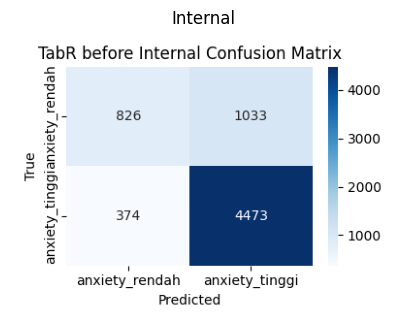

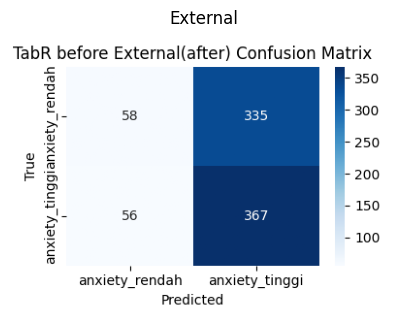


=== INTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score      support
0              0.688333  0.444325  0.540046  1859.000000
1              0.812386  0.922839  0.864097  4847.000000
accuracy       0.790188  0.790188  0.790188     0.790188
macro avg      0.750360  0.683582  0.702072  6706.000000
weighted avg   0.777997  0.790188  0.774266  6706.000000

=== EXTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score     support
0              0.508772  0.147583  0.228797  393.000000
1              0.522792  0.867612  0.652444  423.000000
accuracy       0.520833  0.520833  0.520833    0.520833
macro avg      0.515782  0.507597  0.440621  816.000000
weighted avg   0.516040  0.520833  0.448408  816.000000
=== AFTER | ext=BEFORE ===


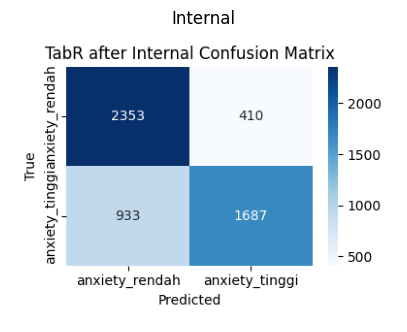

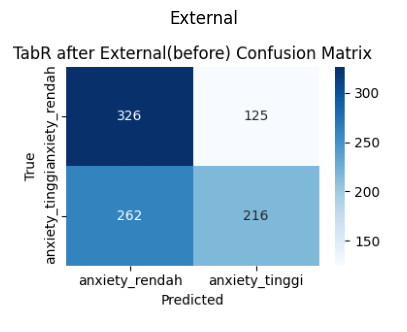


=== INTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score      support
0              0.716068  0.851611  0.777980  2763.000000
1              0.804483  0.643893  0.715285  2620.000000
accuracy       0.750511  0.750511  0.750511     0.750511
macro avg      0.760275  0.747752  0.746632  5383.000000
weighted avg   0.759101  0.750511  0.747465  5383.000000

=== EXTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score     support
0              0.554422  0.722838  0.627526  451.000000
1              0.633431  0.451883  0.527473  478.000000
accuracy       0.583423  0.583423  0.583423    0.583423
macro avg      0.593926  0.587360  0.577499  929.000000
weighted avg   0.595075  0.583423  0.576046  929.000000


In [9]:
for phase in PHASES:
    print(f"=== {phase.upper()} | ext={phase_splits[phase]['external_phase'].upper()} ===")
    visualize_results(phase_dirs[phase])


before /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t31/before/tabr_logs/version_0/metrics.csv


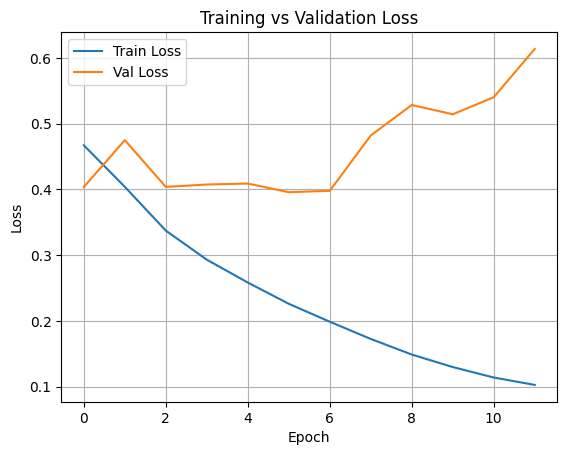

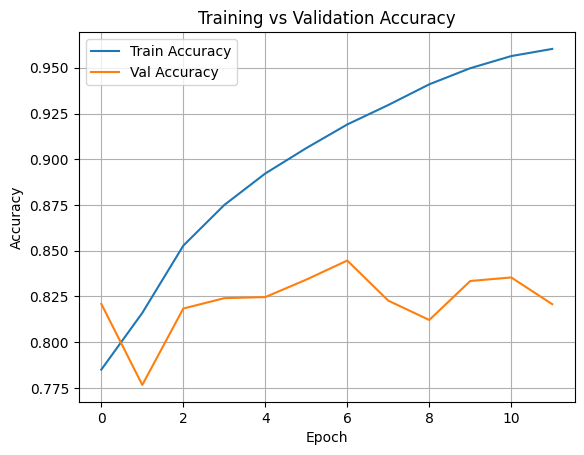

after /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t31/after/tabr_logs/version_0/metrics.csv


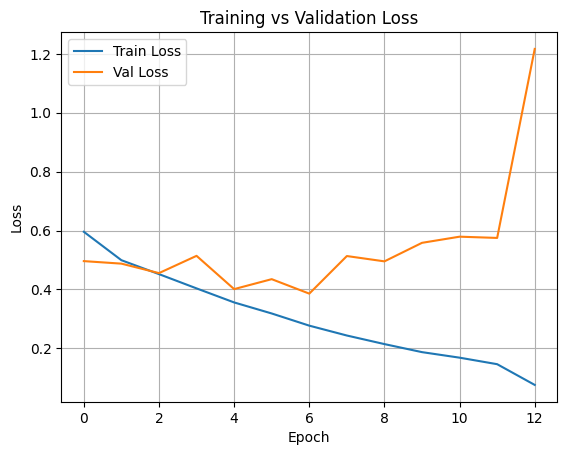

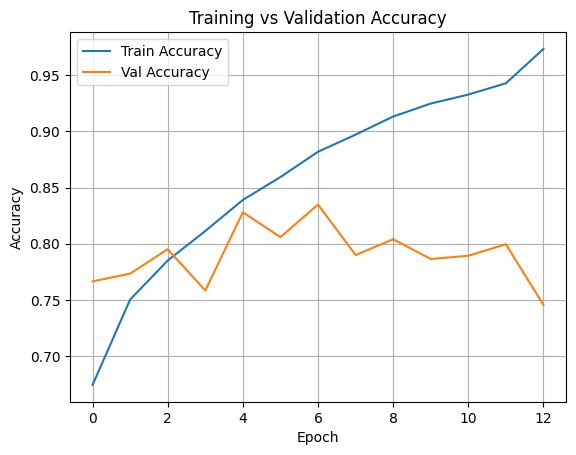

In [10]:
for phase in PHASES:
    metrics_csv = sorted((phase_dirs[phase] / 'tabr_logs').glob('version_*/metrics.csv'))[-1]
    print(phase, metrics_csv)
    plot_lightning_metrics(metrics_csv)


In [11]:
for phase in PHASES:
    print(f"=== {phase.upper()} INTERNAL CM ===")
    print(phase_results[phase]['internal']['cm'])
    print(f"=== {phase.upper()} EXTERNAL CM ({phase_splits[phase]['external_phase'].upper()}) ===")
    print(phase_results[phase]['external']['cm'])


=== BEFORE INTERNAL CM ===
[[ 826 1033]
 [ 374 4473]]
=== BEFORE EXTERNAL CM (AFTER) ===
[[ 58 335]
 [ 56 367]]
=== AFTER INTERNAL CM ===
[[2353  410]
 [ 933 1687]]
=== AFTER EXTERNAL CM (BEFORE) ===
[[326 125]
 [262 216]]


In [12]:
for phase in PHASES:
    split_data = phase_splits[phase]
    print(f"=== DISTRIBUTION [{phase.upper()} -> EXT:{split_data['external_phase'].upper()}] ===")
    print('train rows by label')
    print(split_data['df_tr']['label'].value_counts(dropna=False).sort_index())
    print()
    print('val rows by label')
    print(split_data['df_val']['label'].value_counts(dropna=False).sort_index())
    print()
    print('external rows by label')
    print(split_data['df_external']['label'].value_counts(dropna=False).sort_index())
    print()
    print('train events by label')
    print(split_data['df_tr'][['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
    print()
    print('val events by label')
    print(split_data['df_val'][['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
    print()
    print('external events by label')
    print(split_data['df_external'][['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
    print()


=== DISTRIBUTION [BEFORE -> EXT:AFTER] ===
train rows by label
label
anxiety_rendah     5815
anxiety_tinggi    18472
Name: count, dtype: int64

val rows by label
label
anxiety_rendah    1859
anxiety_tinggi    4847
Name: count, dtype: int64

external rows by label
label
anxiety_rendah    393
anxiety_tinggi    423
Name: count, dtype: int64

train events by label
label
anxiety_rendah    295
anxiety_tinggi    815
Name: count, dtype: int64

val events by label
label
anxiety_rendah     74
anxiety_tinggi    204
Name: count, dtype: int64

external events by label
label
anxiety_rendah    20
anxiety_tinggi    20
Name: count, dtype: int64

=== DISTRIBUTION [AFTER -> EXT:BEFORE] ===
train rows by label
label
anxiety_rendah    11239
anxiety_tinggi    10041
Name: count, dtype: int64

val rows by label
label
anxiety_rendah    2763
anxiety_tinggi    2620
Name: count, dtype: int64

external rows by label
label
anxiety_rendah    451
anxiety_tinggi    478
Name: count, dtype: int64

train events by label


In [13]:
comparison_df


,phase,external_phase,split,accuracy
0,before,after,internal,0.790188
1,before,after,external,0.520833
2,after,before,internal,0.750511
3,after,before,external,0.583423
